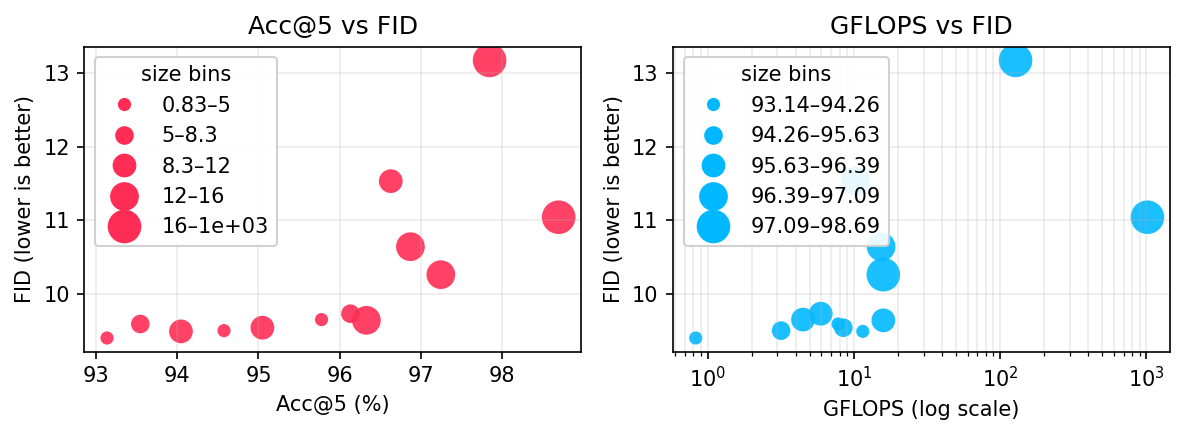

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- Data -----
rows = [
  ("vit_h_14",          98.694, 1016.72, 11.04),
  ("regnet_y_128gf",    97.844, 127.52,  13.17),
  ("regnet_y_16gf_v1",  97.244, 15.91,   10.26),
  ("convnext_base",     96.870, 15.36,   10.64),
  ("efficientnet_b5",   96.628, 10.27,   11.53),
  ("regnet_y_16gf_v2",  96.328, 15.91,    9.64),
  ("swin_v2_t",         96.132, 5.94,     9.73),
  ("swin_t",            95.776, 4.49,     9.65),
  ("regnet_y_32gf",     95.340, 32.28,    None),
  ("regnet_y_8gf",      95.048, 8.47,     9.54),
  ("regnet_y_3_2gf",    94.576, 3.18,     9.50),
  ("resnet152",         94.046, 11.51,    9.49),
  ("resnet101",         93.546, 7.80,     9.59),
  ("regnet_y_800mf",    93.136, 0.83,     9.40),
  ("mobilenet_v3_large",92.566, 0.22,     None),
  ("regnet_y_400mf",    91.716, 0.40,     None),
  ("regnet_x_400mf",    90.950, 0.41,     None),
  ("mobilenet_v2",      90.286, 0.30,     None),
  ("shufflenet_v2_x1_0",88.316, 0.14,     None),
  ("alexnet",           79.066, 0.71,     None),
]

rows = [r for r in rows if r[3] is not None]
names  = np.array([r[0] for r in rows])
acc5   = np.array([r[1] for r in rows], dtype=float)
gflops = np.array([r[2] for r in rows], dtype=float)
fid    = np.array([r[3] for r in rows], dtype=float)

# ----- Helpers -----
N_BINS = 5
SIZE_LEVELS = np.array([40, 80, 130, 190, 260], dtype=float)  # pt^2

def log_quantile_edges(x, n_bins):
    lx = np.log10(x)
    edges = np.quantile(lx, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if edges.size < n_bins + 1:
        edges = np.linspace(lx.min(), lx.max(), n_bins + 1)
    return 10 ** edges

def quantile_edges(x, n_bins):
    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)
    if edges.size < n_bins + 1:
        edges = np.linspace(float(x.min()), float(x.max()), n_bins + 1)
    return edges

def sizes_from_bins(x, edges, size_levels=SIZE_LEVELS):
    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, len(size_levels)-1)
    return size_levels[idx]

# Bin edges & sizes
edges_g = log_quantile_edges(gflops, N_BINS)   # for GFLOPS bins (left size)
sizes_L = sizes_from_bins(gflops, edges_g)

edges_a = quantile_edges(acc5, N_BINS)         # for Acc@5 bins (right size)
sizes_R = sizes_from_bins(acc5, edges_a)

# ----- Subplots (1×2) -----
fig, axes = plt.subplots(1, 2, figsize=(8, 3), dpi=150)

# Left: Acc@5 vs FID  (size = GFLOPS bins), color = #FF2D55
ax = axes[0]
ax.scatter(acc5, fid, s=sizes_L, c="#FF2D55", marker='o', alpha=0.9, edgecolors='none')
ax.set_xlabel("Acc@5 (%)")
ax.set_ylabel("FID (lower is better)")
ax.set_title("Acc@5 vs FID")
ax.grid(True, alpha=0.25)

# Legend with only numeric ranges
handles_L = []
for b, sz in enumerate(SIZE_LEVELS):
    lo = edges_g[b]
    hi = edges_g[b+1] if b+1 < len(edges_g) else None
    label = f"{lo:.2g}–{hi:.2g}" if hi is not None else f">{lo:.2g}"
    handles_L.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#FF2D55",
                            markeredgecolor='none', markersize=(sz**0.5)))
ax.legend(handles=handles_L, title="size bins", loc='best', framealpha=0.9)

# Right: GFLOPS vs FID  (size = Acc@5 bins), color = #00B8FF
ax = axes[1]
ax.scatter(gflops, fid, s=sizes_R, c="#00B8FF", marker='o', alpha=0.9, edgecolors='none')
ax.set_xscale("log")
ax.set_xlabel("GFLOPS (log scale)")
ax.set_ylabel("FID (lower is better)")
ax.set_title("GFLOPS vs FID")
ax.grid(True, which="both", alpha=0.25)

handles_R = []
for b, sz in enumerate(SIZE_LEVELS):
    lo = edges_a[b]
    hi = edges_a[b+1] if b+1 < len(edges_a) else None
    label = f"{lo:.2f}–{hi:.2f}" if hi is not None else f">{lo:.2f}"
    handles_R.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#00B8FF",
                            markeredgecolor='none', markersize=(sz**0.5)))
ax.legend(handles=handles_R, title="size bins", loc='best', framealpha=0.9)

plt.tight_layout()
plt.show()


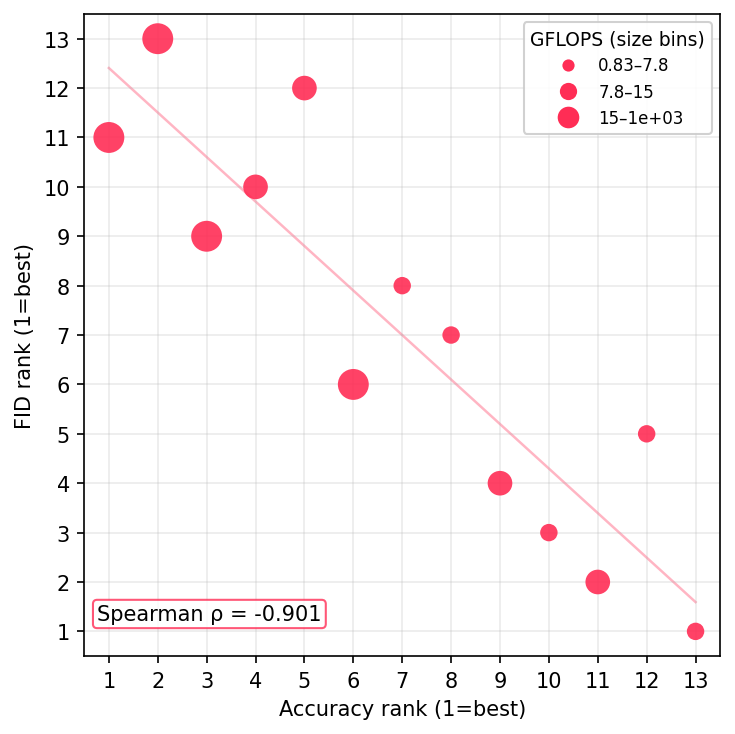

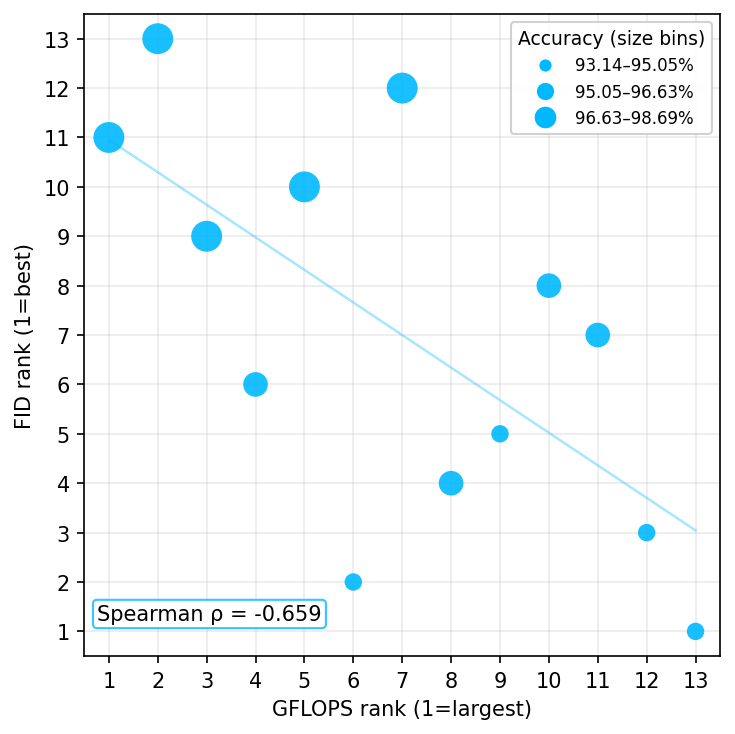

In [24]:
# Update labels to use "Accuracy" (not "Acc" / "Acc@5"). 
# - Left: Accuracy rank vs FID rank (size = GFLOPS bins)
# - Right: GFLOPS rank vs FID rank (size = Accuracy bins)
# Keep: 3-bin legends, lighter regression lines, Spearman rho annotations, legends upper-right, no titles.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----- Data -----
rows = [
  ("vit_h_14",          98.694, 1016.72, 11.04),
  ("regnet_y_128gf",    97.844, 127.52,  13.17),
  ("regnet_y_16gf_v1",  97.244, 15.91,   10.26),
  ("convnext_base",     96.870, 15.36,   10.64),
  ("efficientnet_b5",   96.628, 10.27,   11.53),
  ("regnet_y_16gf_v2",  96.328, 15.91,    9.64),
  ("swin_v2_t",         96.132, 5.94,     9.73),
  ("swin_t",            95.776, 4.49,     9.65),
  ("regnet_y_8gf",      95.048, 8.47,     9.54),
  ("regnet_y_3_2gf",    94.576, 3.18,     9.50),
  ("resnet152",         94.046, 11.51,    9.49),
  ("resnet101",         93.546, 7.80,     9.59),
  ("regnet_y_800mf",    93.136, 0.83,     9.40),
]

accuracy = np.array([r[1] for r in rows], dtype=float)  # Acc@5 values as Accuracy
gflops   = np.array([r[2] for r in rows], dtype=float)
fid      = np.array([r[3] for r in rows], dtype=float)
N = len(fid)

# ----- Ranks (GFLOPS rank: 1=largest) -----
def ranks_from_values(x, ascending=True):
    order = np.argsort(x if ascending else -x)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, len(x)+1, dtype=float)
    return ranks

acc_rank    = ranks_from_values(accuracy, ascending=False)  # 1 = best Accuracy
fid_rank    = ranks_from_values(fid,       ascending=True)  # 1 = best FID
gflops_rank = ranks_from_values(gflops,    ascending=False) # 1 = largest compute

# Spearman rho
def spearman_rho(x, y):
    xm = x.mean(); ym = y.mean()
    num = ((x - xm) * (y - ym)).sum()
    den = np.sqrt(((x - xm)**2).sum() * ((y - ym)**2).sum())
    return float(num / den)

rho_acc_fid    = spearman_rho(acc_rank,    fid_rank)
rho_gflops_fid = spearman_rho(gflops_rank, fid_rank)

# ----- Binning helpers (3 bins) -----
N_BINS = 3
SIZE_LEVELS_G = np.array([70, 140, 220], dtype=float)  # for GFLOPS-driven sizes
SIZE_LEVELS_A = np.array([70, 140, 220], dtype=float)  # for Accuracy-driven sizes

def quantile_edges(x, n_bins):
    e = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    e = np.unique(e)
    if e.size < n_bins + 1:
        e = np.linspace(float(x.min()), float(x.max()), n_bins + 1)
    return e

def log_quantile_edges(x, n_bins):
    lx = np.log10(x + 1e-12)
    e = np.quantile(lx, np.linspace(0, 1, n_bins + 1))
    e = np.unique(e)
    if e.size < n_bins + 1:
        e = np.linspace(lx.min(), lx.max(), n_bins + 1)
    return 10**e

def sizes_from_bins(x, edges, size_levels):
    idx = np.digitize(x, edges) - 1
    idx = np.clip(idx, 0, len(size_levels)-1)
    return size_levels[idx]

# Left plot sizes by GFLOPS (log-quantile bins for ranges)
edges_gflops = log_quantile_edges(gflops, N_BINS)
sizes_left = sizes_from_bins(gflops, edges_gflops, SIZE_LEVELS_G)

# Right plot sizes by Accuracy (quantile bins)
edges_acc = quantile_edges(accuracy, N_BINS)
sizes_right = sizes_from_bins(accuracy, edges_acc, SIZE_LEVELS_A)

# Legend formatting
LEG_FONTSIZE = 8
LEG_TITLE_FONTSIZE = 9
LEG_MARKER_SCALE = 0.7

def format_axes(ax, xlab):
    ax.set_xlabel(xlab)
    ax.set_ylabel("FID rank (1=best)")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0.5, N + 0.5); ax.set_ylim(0.5, N + 0.5)
    ax.set_xticks(range(1, N+1)); ax.set_yticks(range(1, N+1))

# ===== Left: Accuracy rank vs FID rank (size = GFLOPS) =====
plt.figure(figsize=(5, 5), dpi=150)
ax = plt.gca()
ax.scatter(acc_rank, fid_rank, s=sizes_left, c="#FF2D55", marker='o', alpha=0.9, edgecolors='none', zorder=2)
# Regression (light behind)
m1, b1 = np.polyfit(acc_rank, fid_rank, 1)
x1 = np.array([1, N], dtype=float); y1 = m1 * x1 + b1
ax.plot(x1, y1, color="#FF2D55", linewidth=1.2, alpha=0.35, zorder=1)

format_axes(ax, "Accuracy rank (1=best)")

ax.text(0.02, 0.05, f"Spearman ρ = {rho_acc_fid:.3f}", transform=ax.transAxes,
        ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#FF2D55", alpha=0.8))

# Legend — GFLOPS size bins (numeric ranges)
handles_g = []
for b, sz in enumerate(SIZE_LEVELS_G):
    lo = edges_gflops[b]
    hi = edges_gflops[b+1] if b+1 < len(edges_gflops) else None
    label = (f"{lo:.2g}–{hi:.2g}" if hi is not None else f">{lo:.2g}")
    handles_g.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#FF2D55",
                            markeredgecolor='none', markersize=(sz**0.5)*LEG_MARKER_SCALE))
ax.legend(handles=handles_g, title="GFLOPS (size bins)",
          loc='upper right', framealpha=0.9, prop={'size': LEG_FONTSIZE}, title_fontsize=LEG_TITLE_FONTSIZE)

plt.tight_layout()
plt.show()

# ===== Right: GFLOPS rank vs FID rank (size = Accuracy) =====
plt.figure(figsize=(5, 5), dpi=150)
ax = plt.gca()
ax.scatter(gflops_rank, fid_rank, s=sizes_right, c="#00B8FF", marker='o', alpha=0.9, edgecolors='none', zorder=2)
# Regression (light behind)
m2, b2 = np.polyfit(gflops_rank, fid_rank, 1)
x2 = np.array([1, N], dtype=float); y2 = m2 * x2 + b2
ax.plot(x2, y2, color="#00B8FF", linewidth=1.2, alpha=0.35, zorder=1)

format_axes(ax, "GFLOPS rank (1=largest)")

ax.text(0.02, 0.05, f"Spearman ρ = {rho_gflops_fid:.3f}", transform=ax.transAxes,
        ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#00B8FF", alpha=0.8))

# Legend — Accuracy size bins (percent ranges)
handles_a = []
for b, sz in enumerate(SIZE_LEVELS_A):
    lo = edges_acc[b]
    hi = edges_acc[b+1] if b+1 < len(edges_acc) else None
    label = (f"{lo:.2f}–{hi:.2f}%" if hi is not None else f">{lo:.2f}%")
    handles_a.append(Line2D([0],[0], marker='o', color='w',
                            label=label, markerfacecolor="#00B8FF",
                            markeredgecolor='none', markersize=(sz**0.5)*LEG_MARKER_SCALE))
ax.legend(handles=handles_a, title="Accuracy (size bins)",
          loc='upper right', framealpha=0.9, prop={'size': LEG_FONTSIZE}, title_fontsize=LEG_TITLE_FONTSIZE)

plt.tight_layout()
plt.show()
